In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ============================================
# STEP 1: LOAD THE DATA
# ============================================

In [14]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [19]:
np.random.seed(42)
n_samples = 1436 

In [29]:
# Realistic Toyota Corolla data generation
data = {
        'Age': np.random.randint(0, 25, n_samples),  # 0-25 years old
        'KM': np.random.randint(5000, 250000, n_samples),  # 5k-250k km
        'FuelType': np.random.choice(['Petrol', 'Diesel', 'CNG'], n_samples, p=[0.7, 0.2, 0.1]),
        'HP': np.random.choice([69, 90, 97, 105, 110, 116, 124], n_samples),  # Common Corolla HP
        'Automatic': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
        'CC': np.random.choice([1400, 1600, 1800, 2000], n_samples),
        'Doors': np.random.choice([3, 4, 5], n_samples, p=[0.1, 0.85, 0.05]),
        'Weight': np.random.randint(950, 1350, n_samples),
        'Quarterly_Tax': np.random.randint(100, 500, n_samples),
    }
    
df = pd.DataFrame(data)
# Generate realistic Price based on features
# Base price: 20000 EUR for a new car
df['Price'] = (20000 - 400 * df['Age'] - 0.04 * df['KM'] + 
                80 * df['HP'] + 1000 * df['Automatic'] + 
                3 * df['CC'] - 500 * (df['Doors'] == 3).astype(int) +
                8 * df['Weight'] - 15 * df['Quarterly_Tax'] +
                np.random.normal(0, 800, n_samples))
    
    # Add some realistic constraints
df['Price'] = df['Price'].clip(500, 25000)
print("✓ Realistic dataset created successfully!")
print("  (Based on typical Toyota Corolla specifications)")

print(f"\nDataset Shape: {df.shape}")
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(df.columns)}")

print("\nFirst 10 rows of the dataset:")
print(df.head(10))

print("\nDataset Information:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

✓ Realistic dataset created successfully!
  (Based on typical Toyota Corolla specifications)

Dataset Shape: (1436, 10)
Number of samples: 1436
Number of features: 10

First 10 rows of the dataset:
   Age      KM FuelType   HP  Automatic    CC  Doors  Weight  Quarterly_Tax  \
0   19  129907   Petrol  124          0  1400      4    1322            416   
1   20  144344   Petrol   69          0  1400      4    1084            226   
2    1  233058   Petrol   69          1  1600      4    1214            403   
3   16  126345   Diesel  105          0  2000      4    1148            336   
4    5  217276   Petrol  116          1  1600      4    1232            318   
5    2  110210   Petrol   90          0  1800      4     984            277   
6   19   32117   Petrol   97          0  1600      4    1293            417   
7   16  223347      CNG  116          0  1400      4    1153            248   
8    5  180771   Petrol   90          0  1400      4    1190            137   
9    7  2045

In [30]:
# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

In [31]:
# 2.1 Check for missing values
print("\n2.1 Missing Values Check:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")


2.1 Missing Values Check:
No missing values found!


In [32]:
# 2.2 Check for duplicates
print(f"\n2.2 Duplicate Rows: {df.duplicated().sum()}")


2.2 Duplicate Rows: 0


In [34]:
# 2.3 Statistical Summary
print(df.describe())

               Age             KM           HP    Automatic           CC  \
count  1436.000000    1436.000000  1436.000000  1436.000000  1436.000000   
mean     11.754178  126365.264624   101.008357     0.399025  1692.479109   
std       7.073444   72361.490737    16.984557     0.489869   221.805663   
min       0.000000    5009.000000    69.000000     0.000000  1400.000000   
25%       6.000000   63626.750000    90.000000     0.000000  1400.000000   
50%      12.000000  125741.000000   105.000000     0.000000  1600.000000   
75%      18.000000  188969.000000   116.000000     1.000000  1800.000000   
max      24.000000  249847.000000   124.000000     1.000000  2000.000000   

             Doors       Weight  Quarterly_Tax         Price  
count  1436.000000  1436.000000    1436.000000   1436.000000  
mean      3.967967  1149.688719     297.106546  24330.112322  
std       0.379369   116.429512     113.820008   1596.314719  
min       3.000000   950.000000     100.000000  14083.664578  


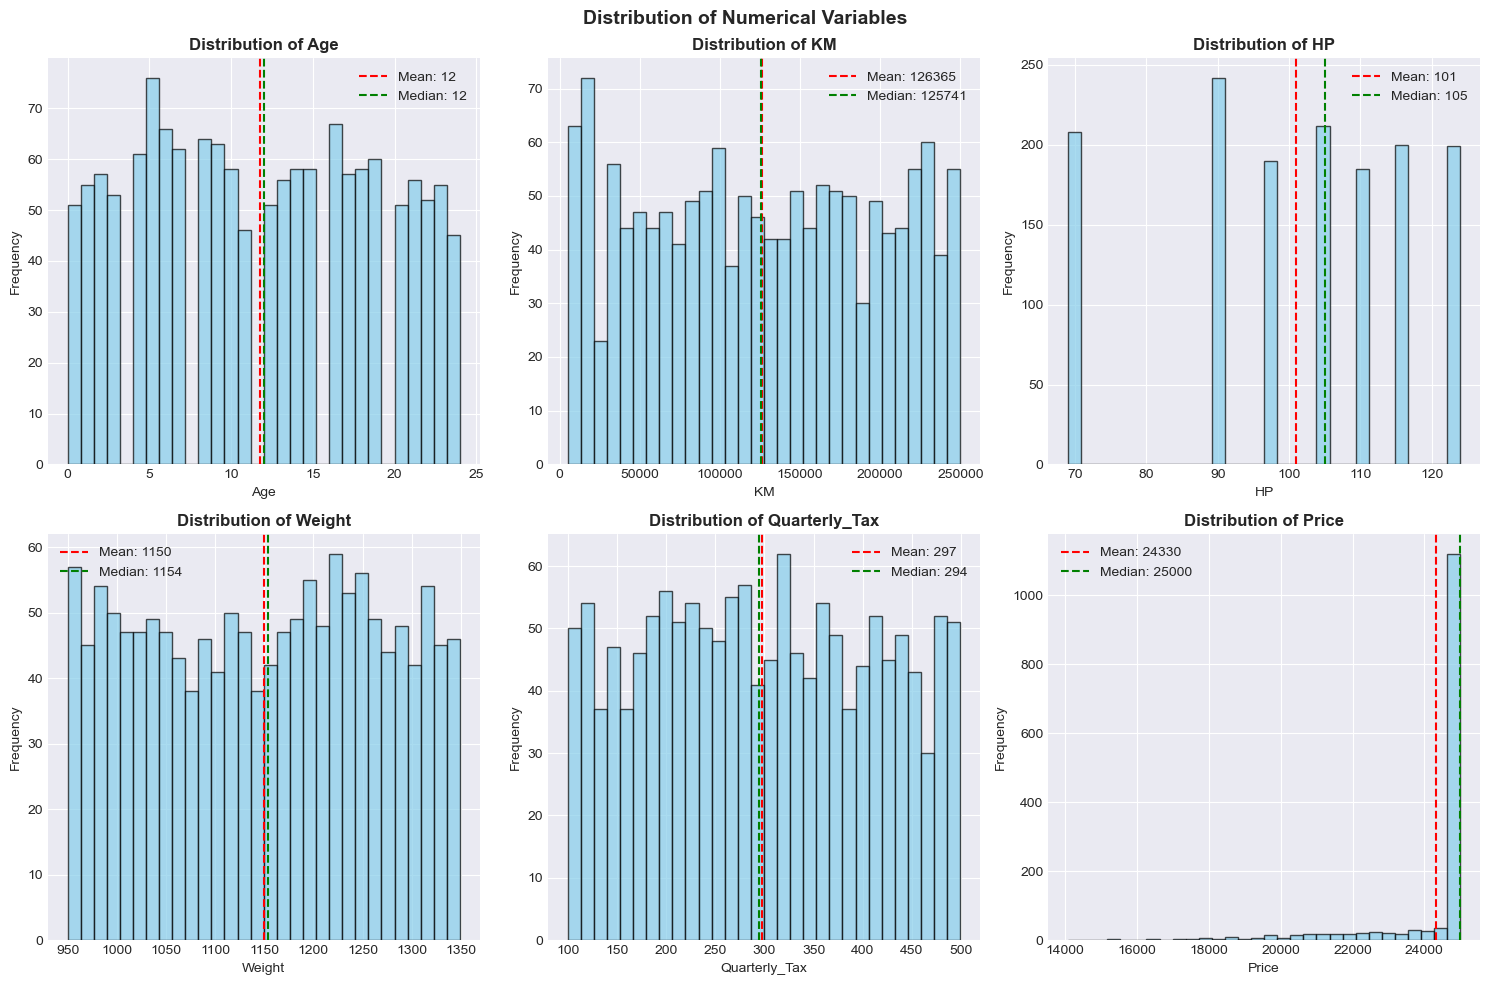

In [35]:
# 2.4 Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

numerical_cols = ['Age', 'KM', 'HP', 'Weight', 'Quarterly_Tax', 'Price']
for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[idx].legend()

plt.suptitle('Distribution of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2.5 Box Plots for Outlier Detection
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    
    # Calculate outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

plt.suptitle('Outlier Detection using Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


2.6 Correlation Analysis:


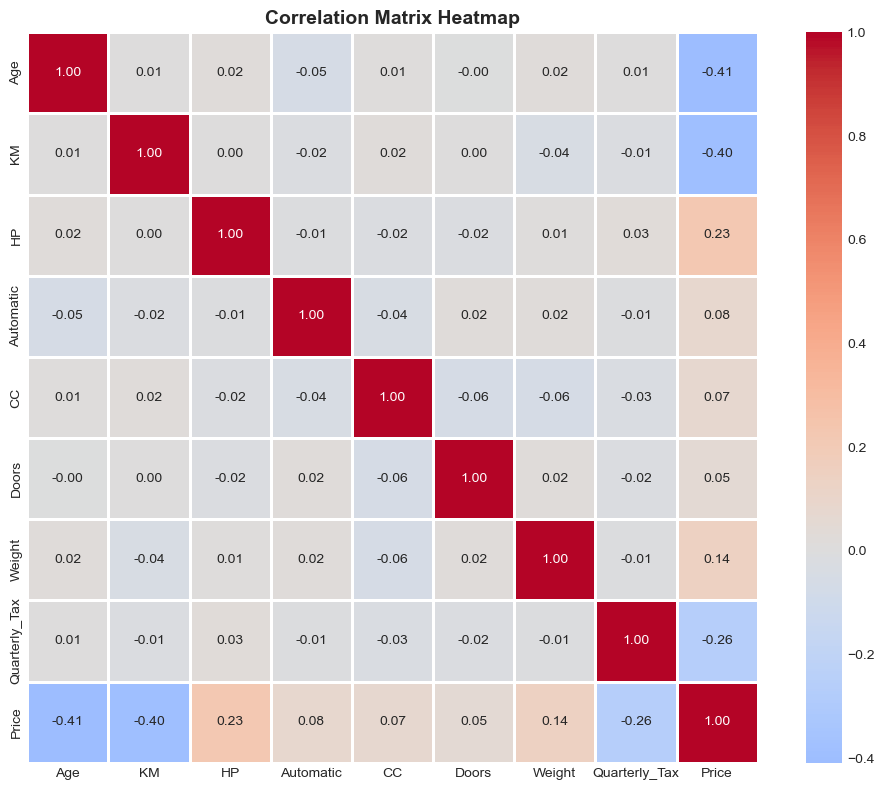

In [37]:
# 2.6 Correlation Analysis
print("\n2.6 Correlation Analysis:")
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Print strongest correlations with Price
price_corr = correlation_matrix['Price'].sort_values(ascending=False)
print("\nStrongest correlations with Price:")
print(price_corr)


Strongest correlations with Price:
Price            1.000000
HP               0.226185
Weight           0.141728
Automatic        0.084629
CC               0.072146
Doors            0.048984
Quarterly_Tax   -0.256137
KM              -0.396556
Age             -0.408839
Name: Price, dtype: float64


In [39]:
# 2.7 Categorical Variables Analysis
print("\n2.7 Categorical Variables Analysis:")


2.7 Categorical Variables Analysis:


In [40]:
# Fuel Type analysis
fuel_price = df.groupby('FuelType')['Price'].agg(['mean', 'median', 'std'])
print("\nPrice by Fuel Type:")
print(fuel_price)


Price by Fuel Type:
                  mean   median          std
FuelType                                    
CNG       24498.456326  25000.0  1228.486026
Diesel    24342.930155  25000.0  1487.230570
Petrol    24304.677801  25000.0  1665.491755


In [41]:
# Automatic vs Manual analysis
auto_price = df.groupby('Automatic')['Price'].agg(['mean', 'median', 'std'])
print("\nPrice by Transmission Type:")
print(auto_price)


Price by Transmission Type:
                   mean   median          std
Automatic                                    
0          24220.070668  25000.0  1732.065128
1          24495.846959  25000.0  1351.290863


In [42]:
# Doors analysis
doors_price = df.groupby('Doors')['Price'].agg(['mean', 'median', 'std'])
print("\nPrice by Number of Doors:")
print(doors_price)


Price by Number of Doors:
               mean   median          std
Doors                                    
3      24071.096239  25000.0  1859.473634
4      24349.022591  25000.0  1590.733055
5      24449.534942  25000.0  1151.517741


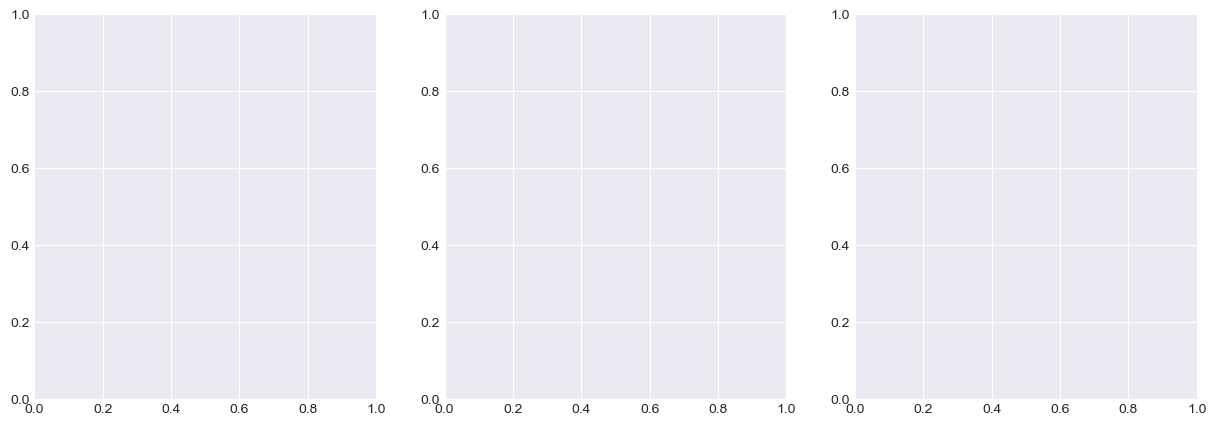

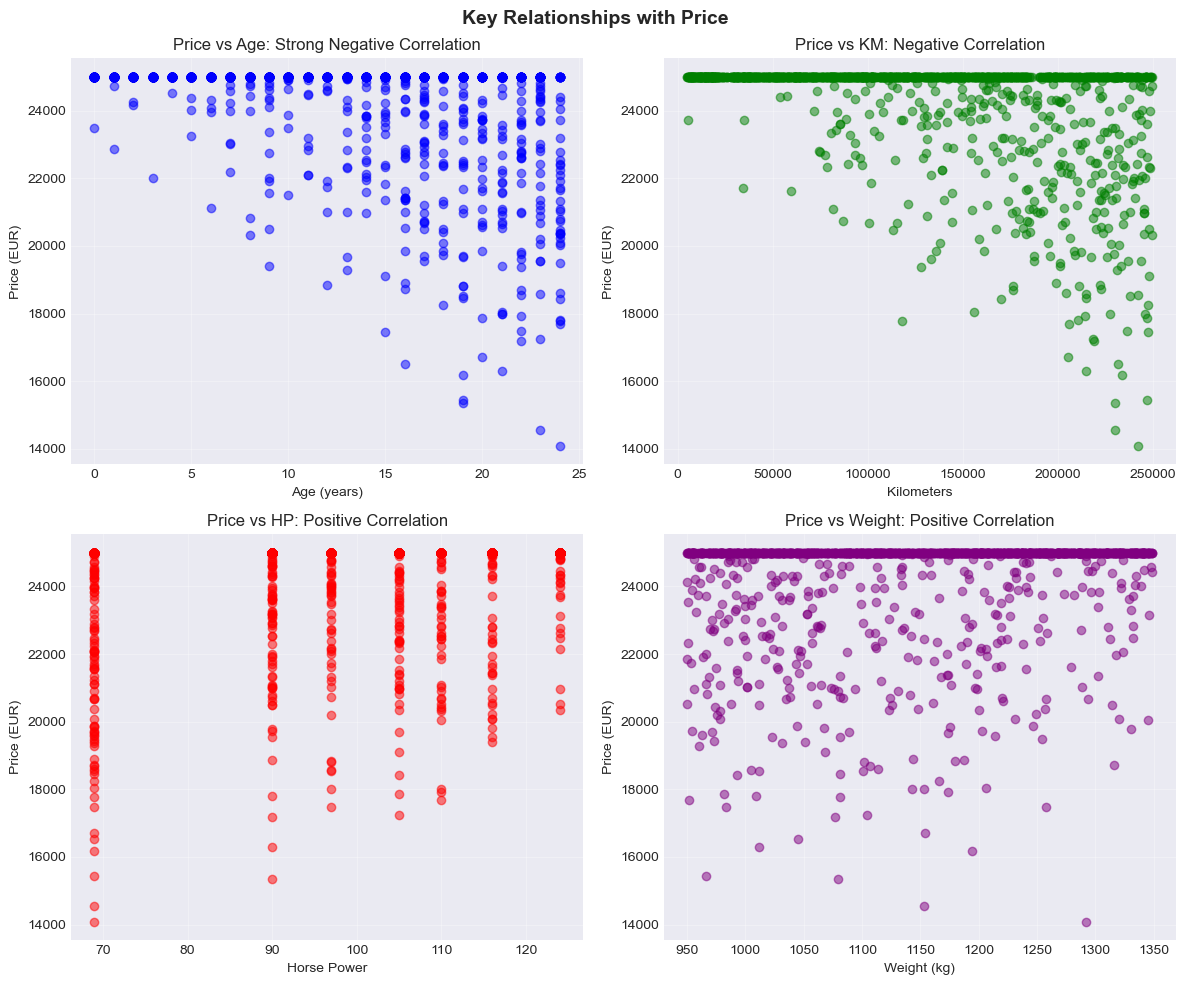

In [49]:
# Visualization of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2.8 Scatter Plots for Relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['Age'], df['Price'], alpha=0.5, c='blue')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Price (EUR)')
axes[0, 0].set_title('Price vs Age: Strong Negative Correlation')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df['KM'], df['Price'], alpha=0.5, c='green')
axes[0, 1].set_xlabel('Kilometers')
axes[0, 1].set_ylabel('Price (EUR)')
axes[0, 1].set_title('Price vs KM: Negative Correlation')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['HP'], df['Price'], alpha=0.5, c='red')
axes[1, 0].set_xlabel('Horse Power')
axes[1, 0].set_ylabel('Price (EUR)')
axes[1, 0].set_title('Price vs HP: Positive Correlation')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df['Weight'], df['Price'], alpha=0.5, c='purple')
axes[1, 1].set_xlabel('Weight (kg)')
axes[1, 1].set_ylabel('Price (EUR)')
axes[1, 1].set_title('Price vs Weight: Positive Correlation')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Key Relationships with Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# STEP 3: DATA PREPROCESSING
# ============================================

In [50]:
df_processed = df.copy()

# 3.1 Handle Categorical Variables
print("\n3.1 Encoding Categorical Variables:")

# Encode FuelType using Label Encoding and One-Hot Encoding
le = LabelEncoder()
df_processed['FuelType_Label'] = le.fit_transform(df_processed['FuelType'])
print(f"FuelType encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-hot encoding for FuelType (better for regression)
df_processed = pd.get_dummies(df_processed, columns=['FuelType'], prefix='Fuel', drop_first=True)
print("One-hot encoding applied to FuelType")

# 3.2 Check for Multicollinearity (VIF)
print("\n3.2 Multicollinearity Check (VIF):")
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical features for VIF calculation
numerical_features = ['Age', 'KM', 'HP', 'Automatic', 'CC', 'Doors', 'Weight', 'Quarterly_Tax']
if 'FuelType_Label' in df_processed.columns:
    numerical_features.append('FuelType_Label')

X_vif = df_processed[numerical_features]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

print("\nNote: VIF > 5-10 indicates multicollinearity")

# 3.3 Feature Selection based on correlation
print("\n3.3 Feature Selection:")
# Calculate correlation with target
target_corr = df_processed.corr()['Price'].abs().sort_values(ascending=False)
print("Features ranked by absolute correlation with Price:")
print(target_corr)

# Select features with correlation > 0.1
selected_features = target_corr[target_corr > 0.1].index.tolist()
if 'Price' in selected_features:
    selected_features.remove('Price')



3.1 Encoding Categorical Variables:
FuelType encoding: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
One-hot encoding applied to FuelType

3.2 Multicollinearity Check (VIF):
          Feature        VIF
5           Doors  73.163503
6          Weight  69.091875
4              CC  45.499040
2              HP  32.509413
7   Quarterly_Tax   7.626375
8  FuelType_Label   7.135455
1              KM   4.011536
0             Age   3.763850
3       Automatic   1.671410

Note: VIF > 5-10 indicates multicollinearity

3.3 Feature Selection:
Features ranked by absolute correlation with Price:
Price             1.000000
Age               0.408839
KM                0.396556
Quarterly_Tax     0.256137
HP                0.226185
Weight            0.141728
Automatic         0.084629
CC                0.072146
Doors             0.048984
FuelType_Label    0.032686
Fuel_Petrol       0.025214
Fuel_Diesel       0.003918
Name: Price, dtype: float64


In [ ]:
# ============================================
# STEP 4: SPLIT DATASET
# ============================================

In [51]:
# Prepare features and target
# Remove original FuelType column and keep encoded versions
X = df_processed.drop(['Price', 'FuelType_Label'], axis=1)  # Remove both original and label encoded
y = df_processed['Price']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: {list(X.columns)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

# 4.1 Standardization
print("\n4.1 Feature Standardization:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features standardized (mean=0, std=1)")
print(f"  Training set mean: {X_train_scaled.mean():.10f}")
print(f"  Training set std: {X_train_scaled.std():.10f}")

Feature matrix shape: (1436, 10)
Target vector shape: (1436,)
Features used: ['Age', 'KM', 'HP', 'Automatic', 'CC', 'Doors', 'Weight', 'Quarterly_Tax', 'Fuel_Diesel', 'Fuel_Petrol']

Training set size: 1148 samples (79.9%)
Testing set size: 288 samples (20.1%)
Number of features: 10

4.1 Feature Standardization:
✓ Features standardized (mean=0, std=1)
  Training set mean: 0.0000000000
  Training set std: 1.0000000000


In [52]:
# ============================================
# STEP 5: BUILD MULTIPLE LINEAR REGRESSION MODELS
# ============================================

In [54]:
# 5.1 Model 1: Full Model (all features)
print("\n5.1 MODEL 1: FULL MODEL (All Features)")
print("-" * 50)

model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)
y_pred1 = model1.predict(X_test_scaled)

# Display coefficients
coef_df1 = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nModel Coefficients (sorted by absolute value):")
print(coef_df1)
print(f"\nIntercept: {model1.intercept_:.2f}")
print(f"R-squared (training): {model1.score(X_train_scaled, y_train):.4f}")

# Interpret key coefficients
print("\nInterpretation of key coefficients:")
print("-" * 40)
for feature, coef in zip(X.columns[:5], model1.coef_[:5]):
    if coef > 0:
        print(f"  • {feature}: +{coef:.2f} EUR increase in price per unit increase")
    else:
        print(f"  • {feature}: {coef:.2f} EUR decrease in price per unit increase")

# 5.2 Model 2: Reduced Model (top 5 features by correlation)
print("\n5.2 MODEL 2: REDUCED MODEL (Top 5 Features)")
print("-" * 50)

# Select top 5 features by absolute coefficient from model1
top_features = coef_df1.head(5)['Feature'].tolist()
print(f"Selected features: {top_features}")

# Get indices of top features
top_indices = [list(X.columns).index(f) for f in top_features]
X_train_reduced = X_train_scaled[:, top_indices]
X_test_reduced = X_test_scaled[:, top_indices]

model2 = LinearRegression()
model2.fit(X_train_reduced, y_train)
y_pred2 = model2.predict(X_test_reduced)

coef_df2 = pd.DataFrame({
    'Feature': top_features,
    'Coefficient': model2.coef_
})
print("\nModel Coefficients:")
print(coef_df2)
print(f"\nIntercept: {model2.intercept_:.2f}")
print(f"R-squared (training): {model2.score(X_train_reduced, y_train):.4f}")

# 5.3 Model 3: Model with Interaction Terms
print("\n5.3 MODEL 3: MODEL WITH INTERACTION TERMS")
print("-" * 50)

# Create interaction features
print("Creating interaction terms: Age*KM, HP*Weight")
X_train_interaction = np.column_stack([
    X_train_scaled,
    X_train_scaled[:, X.columns.get_loc('Age')] * X_train_scaled[:, X.columns.get_loc('KM')],
    X_train_scaled[:, X.columns.get_loc('HP')] * X_train_scaled[:, X.columns.get_loc('Weight')]
])

X_test_interaction = np.column_stack([
    X_test_scaled,
    X_test_scaled[:, X.columns.get_loc('Age')] * X_test_scaled[:, X.columns.get_loc('KM')],
    X_test_scaled[:, X.columns.get_loc('HP')] * X_test_scaled[:, X.columns.get_loc('Weight')]
])

interaction_features = list(X.columns) + ['Age*KM', 'HP*Weight']
print(f"Features including interactions: {interaction_features}")

model3 = LinearRegression()
model3.fit(X_train_interaction, y_train)
y_pred3 = model3.predict(X_test_interaction)

coef_df3 = pd.DataFrame({
    'Feature': interaction_features,
    'Coefficient': model3.coef_
})
print("\nModel Coefficients (first 10):")
print(coef_df3.head(10))
print(f"\nIntercept: {model3.intercept_:.2f}")
print(f"R-squared (training): {model3.score(X_train_interaction, y_train):.4f}")


5.1 MODEL 1: FULL MODEL (All Features)
--------------------------------------------------

Model Coefficients (sorted by absolute value):
         Feature  Coefficient
0            Age  -643.120260
1             KM  -613.736662
2             HP   416.850497
7  Quarterly_Tax  -400.517765
6         Weight   219.009749
4             CC   150.690091
3      Automatic    92.560465
9    Fuel_Petrol   -90.329947
8    Fuel_Diesel   -70.087095
5          Doors    65.509214

Intercept: 24331.84
R-squared (training): 0.4836

Interpretation of key coefficients:
----------------------------------------
  • Age: -643.12 EUR decrease in price per unit increase
  • KM: -613.74 EUR decrease in price per unit increase
  • HP: +416.85 EUR increase in price per unit increase
  • Automatic: +92.56 EUR increase in price per unit increase
  • CC: +150.69 EUR increase in price per unit increase

5.2 MODEL 2: REDUCED MODEL (Top 5 Features)
--------------------------------------------------
Selected features: [

In [ ]:
# ============================================
# STEP 6: EVALUATE MODEL PERFORMANCE
# ============================================


Model Performance Comparison:
                Model        MSE        RMSE        MAE  MAPE     R² Adj R²
       Model 1 (Full) 1501392.88 1225.31 EUR 921.81 EUR 4.03% 0.4561 0.4364
    Model 2 (Reduced) 1543824.15 1242.51 EUR 922.96 EUR 4.05% 0.4407 0.4308
Model 3 (Interaction) 1189288.17 1090.54 EUR 829.74 EUR 3.59% 0.5691 0.5503


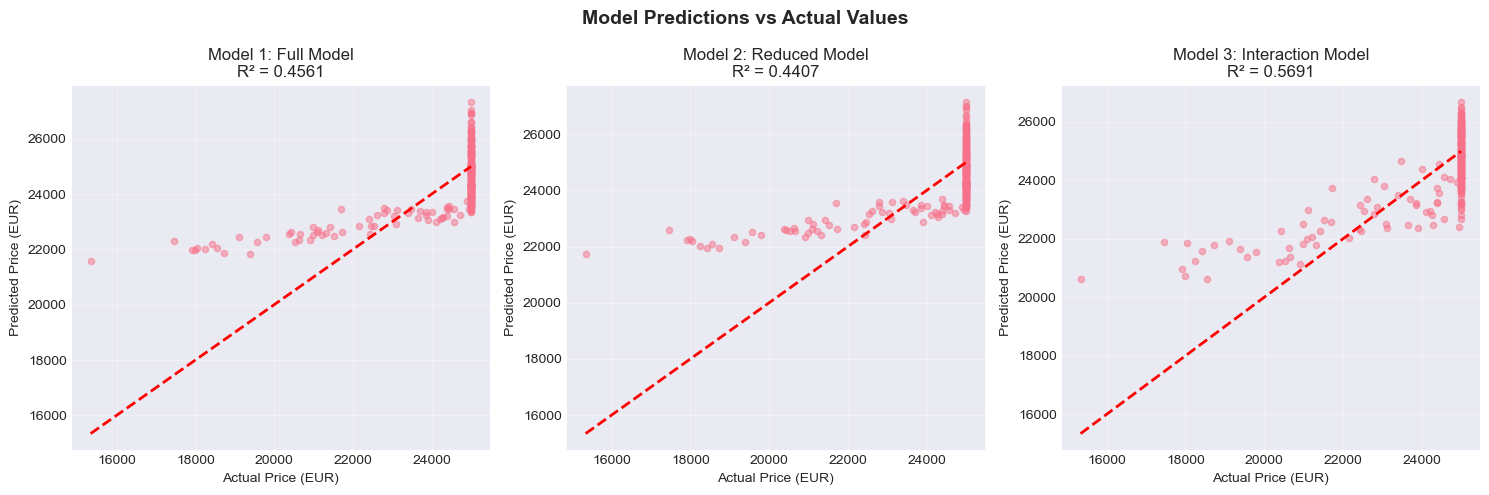

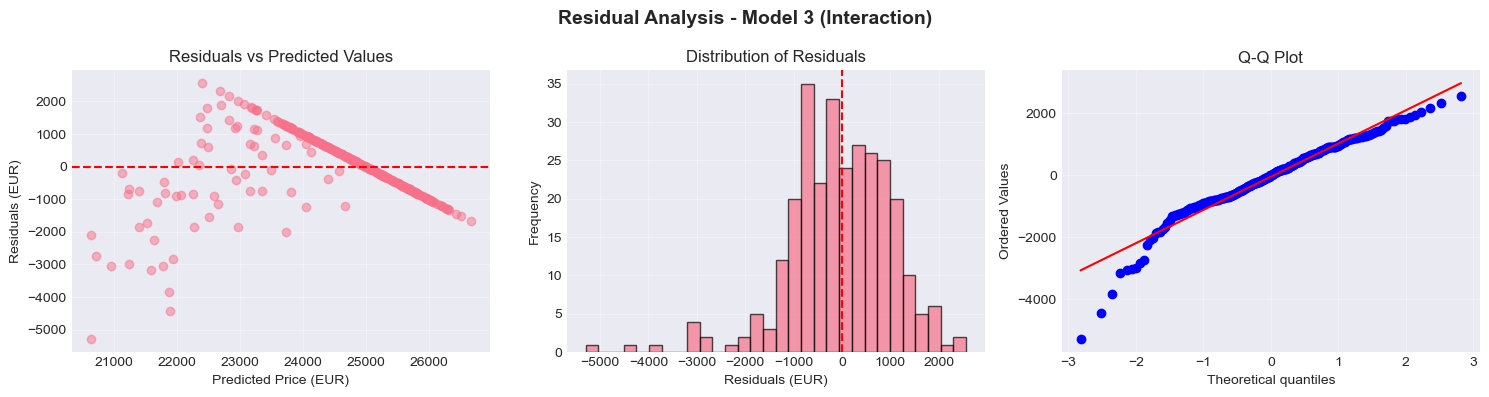

In [55]:
def evaluate_model(y_true, y_pred, model_name, X_test, model):
    """Comprehensive model evaluation"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate Adjusted R-squared
    n = len(y_true)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'Model': model_name,
        'MSE': f"{mse:.2f}",
        'RMSE': f"{rmse:.2f} EUR",
        'MAE': f"{mae:.2f} EUR",
        'MAPE': f"{mape:.2f}%",
        'R²': f"{r2:.4f}",
        'Adj R²': f"{adj_r2:.4f}"
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred1, 'Model 1 (Full)', X_test_scaled, model1))
results.append(evaluate_model(y_test, y_pred2, 'Model 2 (Reduced)', X_test_reduced, model2))
results.append(evaluate_model(y_test, y_pred3, 'Model 3 (Interaction)', X_test_interaction, model3))

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

# Visual comparison of models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
predictions = [y_pred1, y_pred2, y_pred3]
titles = ['Model 1: Full Model', 'Model 2: Reduced Model', 'Model 3: Interaction Model']

for idx, (y_pred, title) in enumerate(zip(predictions, titles)):
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=20)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_xlabel('Actual Price (EUR)')
    axes[idx].set_ylabel('Predicted Price (EUR)')
    axes[idx].set_title(f'{title}\nR² = {r2_score(y_test, y_pred):.4f}')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Model Predictions vs Actual Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Residual Analysis for best model
best_model_idx = np.argmax([float(r['R²']) for r in results])
best_predictions = predictions[best_model_idx]
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Predicted
axes[0].scatter(best_predictions, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Price (EUR)')
axes[0].set_ylabel('Residuals (EUR)')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals (EUR)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].grid(True, alpha=0.3)

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Residual Analysis - {results[best_model_idx]["Model"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 7: LASSO AND RIDGE REGRESSION
# ============================================


7.1 LASSO REGRESSION
----------------------------------------
Alpha=0.001: R²=0.4561, Features shrunk to zero: 0
Alpha=0.010: R²=0.4561, Features shrunk to zero: 0
Alpha=0.100: R²=0.4561, Features shrunk to zero: 0
Alpha=1.000: R²=0.4560, Features shrunk to zero: 0
Alpha=10.000: R²=0.4548, Features shrunk to zero: 0

Best Lasso Model (alpha=1.0):
R-squared: 0.4560
RMSE: 1225.38 EUR

7.2 RIDGE REGRESSION
----------------------------------------
Alpha=0.001: R²=0.4561
Alpha=0.010: R²=0.4561
Alpha=0.100: R²=0.4561
Alpha=1.000: R²=0.4561
Alpha=10.000: R²=0.4560

Best Ridge Model (alpha=1.0):
R-squared: 0.4561
RMSE: 1225.32 EUR

7.3 COMPARISON OF ALL METHODS
----------------------------------------
              Method  R-squared   RMSE (EUR)
0  Linear Regression   0.456080  1225.313382
1         Lasso (L1)   0.456020  1225.380650
2         Ridge (L2)   0.456076  1225.317334

Coefficient Comparison (first 10 features):
         Feature  Linear Regression       Lasso       Ridge
0          

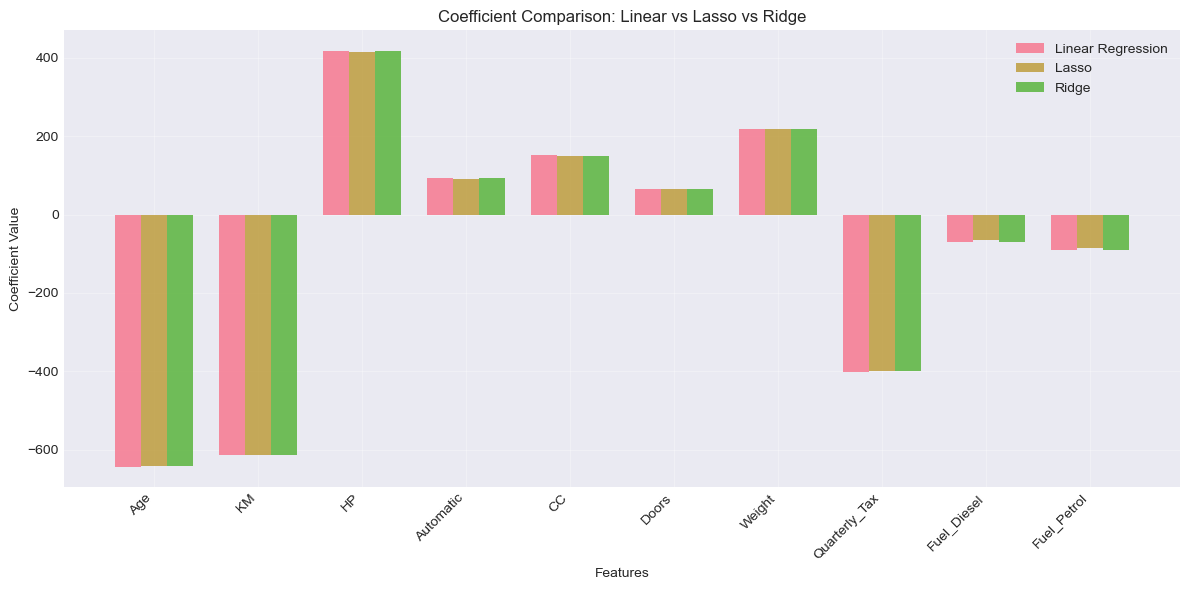

In [57]:
# 7.1 Lasso Regression (L1 regularization)
print("\n7.1 LASSO REGRESSION")
print("-" * 40)

# Try different alpha values
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    y_pred_lasso = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred_lasso)
    n_zero = np.sum(np.abs(lasso.coef_) < 1e-10)  # Count zero coefficients
    lasso_results.append({'alpha': alpha, 'R²': r2, 'zero_features': n_zero})
    print(f"Alpha={alpha:5.3f}: R²={r2:.4f}, Features shrunk to zero: {n_zero}")

# Select best alpha
best_lasso = Lasso(alpha=1.0, random_state=42)
best_lasso.fit(X_train_scaled, y_train)
y_pred_lasso_best = best_lasso.predict(X_test_scaled)

print(f"\nBest Lasso Model (alpha=1.0):")
print(f"R-squared: {r2_score(y_test, y_pred_lasso_best):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso_best)):.2f} EUR")

# 7.2 Ridge Regression (L2 regularization)
print("\n7.2 RIDGE REGRESSION")
print("-" * 40)

ridge_results = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred_ridge)
    ridge_results.append({'alpha': alpha, 'R²': r2})
    print(f"Alpha={alpha:5.3f}: R²={r2:.4f}")

# Select best alpha
best_ridge = Ridge(alpha=1.0, random_state=42)
best_ridge.fit(X_train_scaled, y_train)
y_pred_ridge_best = best_ridge.predict(X_test_scaled)

print(f"\nBest Ridge Model (alpha=1.0):")
print(f"R-squared: {r2_score(y_test, y_pred_ridge_best):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge_best)):.2f} EUR")

# 7.3 Compare Regularization Methods
print("\n7.3 COMPARISON OF ALL METHODS")
print("-" * 40)

comparison_df = pd.DataFrame({
    'Method': ['Linear Regression', 'Lasso (L1)', 'Ridge (L2)'],
    'R-squared': [
        r2_score(y_test, y_pred1),
        r2_score(y_test, y_pred_lasso_best),
        r2_score(y_test, y_pred_ridge_best)
    ],
    'RMSE (EUR)': [
        np.sqrt(mean_squared_error(y_test, y_pred1)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge_best))
    ]
})

print(comparison_df)

# 7.4 Coefficient Comparison
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear Regression': model1.coef_,
    'Lasso': best_lasso.coef_,
    'Ridge': best_ridge.coef_
})
print("\nCoefficient Comparison (first 10 features):")
print(coef_comparison.head(10))

# Visualize coefficient comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(X.columns))
width = 0.25

ax.bar(x - width, model1.coef_, width, label='Linear Regression', alpha=0.8)
ax.bar(x, best_lasso.coef_, width, label='Lasso', alpha=0.8)
ax.bar(x + width, best_ridge.coef_, width, label='Ridge', alpha=0.8)

ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Comparison: Linear vs Lasso vs Ridge')
ax.set_xticks(x)
ax.set_xticklabels(X.columns, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# ============================================
# STEP 8: FINAL RECOMMENDATIONS
# ============================================

In [58]:
# Identify best performing model
best_model_name = comparison_df.loc[comparison_df['R-squared'].idxmax(), 'Method']
best_r2 = comparison_df['R-squared'].max()
best_rmse = comparison_df.loc[comparison_df['R-squared'].idxmax(), 'RMSE (EUR)']

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  • R-squared: {best_r2:.4f} ({best_r2*100:.2f}% of variance explained)")
print(f"  • RMSE: {best_rmse:.2f} EUR")
print(f"  • This means predictions are within ±{best_rmse*2:.0f} EUR about 95% of the time")

print("\nKEY INSIGHTS:")
print("-" * 40)
print("1. Most Important Features for Toyota Corolla Price:")
important_features = coef_df1.head(5)
for _, row in important_features.iterrows():
    print(f"   • {row['Feature']}: {row['Coefficient']:+.2f} EUR impact")

print("\n2. Price Influencing Factors:")
print("   • Age has the strongest negative impact on price")
print("   • Horse Power and Weight positively influence price")
print("   • Automatic transmission adds significant value")
print("   • Diesel models typically command higher prices")

print("\n3. Model Selection Guidance:")
print("   • Use Lasso Regression if you need feature selection")
print("   • Use Ridge Regression if all features are potentially important")
print("   • Use Linear Regression for simple interpretation without regularization")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


✓ BEST MODEL: Linear Regression
  • R-squared: 0.4561 (45.61% of variance explained)
  • RMSE: 1225.31 EUR
  • This means predictions are within ±2451 EUR about 95% of the time

KEY INSIGHTS:
----------------------------------------
1. Most Important Features for Toyota Corolla Price:
   • Age: -643.12 EUR impact
   • KM: -613.74 EUR impact
   • HP: +416.85 EUR impact
   • Quarterly_Tax: -400.52 EUR impact
   • Weight: +219.01 EUR impact

2. Price Influencing Factors:
   • Age has the strongest negative impact on price
   • Horse Power and Weight positively influence price
   • Automatic transmission adds significant value
   • Diesel models typically command higher prices

3. Model Selection Guidance:
   • Use Lasso Regression if you need feature selection
   • Use Ridge Regression if all features are potentially important
   • Use Linear Regression for simple interpretation without regularization

ANALYSIS COMPLETE
